## Generating plots from the trained models

In [127]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 1- Forecasts VS Ground Truth

In [128]:
base_dir = "predictions"
models = {
    "lstm": "./predictions/lstm/predictions_lstm_target_delta_y.csv",
    "arima": "./predictions/arima/predictions_arima_target_delta_y.csv",
    "prophet": "./predictions/prophet/predictions_prophet_target_delta_y.csv",
    "random_forest": "./predictions/random_forest/predictions_random_forest_target_delta_y.csv"
}

In [4]:
data_3 = pd.read_csv("./Macro_lag_1_delta_y_delta_lags.csv")

data_3.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
0,422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534
1,482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102
2,542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825
3,602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918
4,662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057


In [5]:
data_3 = data_3.set_index('t')

In [6]:
split = int(len(data_3) * 0.8)

train_3, test_3 = data_3.iloc[:split], data_3.iloc[split:]

In [140]:
len(train_3)

112

In [141]:
len(test_3)

28

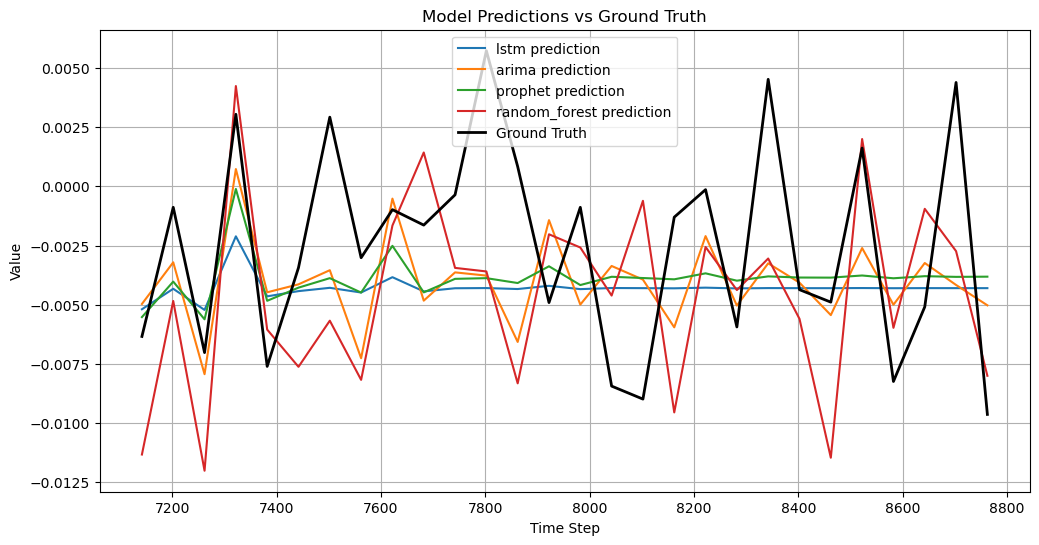

In [129]:
plt.figure(figsize=(12, 6))

for model_name, file_name in models.items():
    df = pd.read_csv(file_name)

    # --- detect columns safely ---
    if "y_true" in df.columns:
        y_true = df["y_true"]

    if "y_pred" in df.columns:
        y_pred = df["y_pred"]

    plt.plot(test_3.index,y_pred, label=f"{model_name} prediction")

# plot ground truth once (from first model)
plt.plot(test_3.index,y_true, label="Ground Truth", color="black", linewidth=2)

plt.title("Model Predictions vs Ground Truth")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

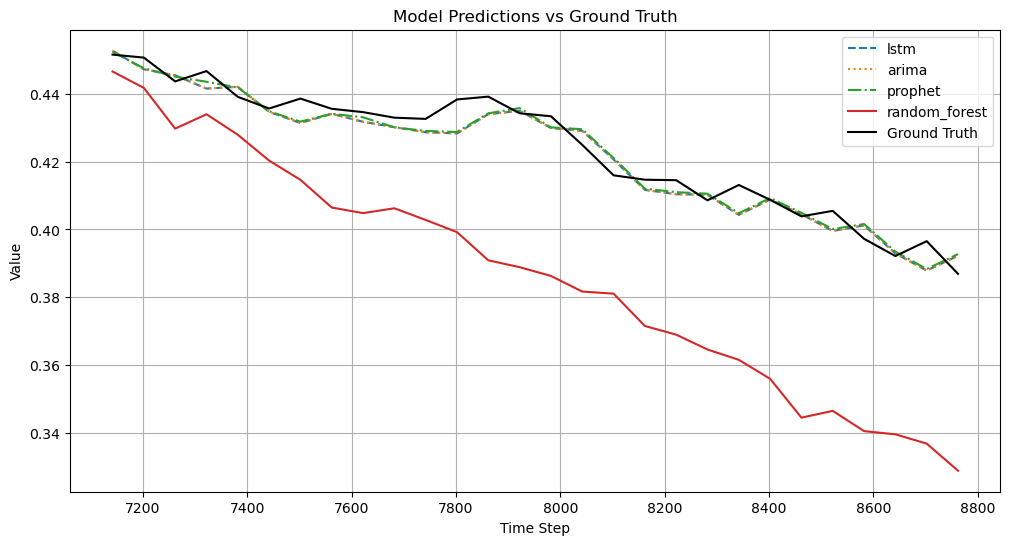

In [7]:
plt.figure(figsize=(12, 6))

for model_name, file_name in models.items():
    df = pd.read_csv(file_name)

    if "reconstructed" in df.columns:
        y_pred = df["reconstructed"]
        
    if model_name.lower() == "lstm":
        style = "--"
    elif model_name.lower() == "arima":
        style = ":"
    elif model_name.lower() == "prophet":
        style = "-."
    else:
        style = "-"

    # --- plot ---
    plt.plot(test_3.index, y_pred, label=f"{model_name}", linestyle=style)

# plot ground truth once (from first model)
plt.plot(test_3.index,test_3["A_sample_noisy"], label="Ground Truth", color="black")

plt.title("Model Predictions vs Ground Truth")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
for model_name, file_name in models.items():
    df = pd.read_csv(file_name)

    if "reconstructed" in df.columns:
        y_pred = df["reconstructed"]
        
    if model_name.lower() == "lstm":
        y_pred_lstm = y_pred
    elif model_name.lower() == "arima":
        y_pred_arima = y_pred
    elif model_name.lower() == "prophet":
        y_pred_prophet = y_pred
    else:
        y_pred_rf = y_pred

y_true = test_3["A_sample_noisy"]

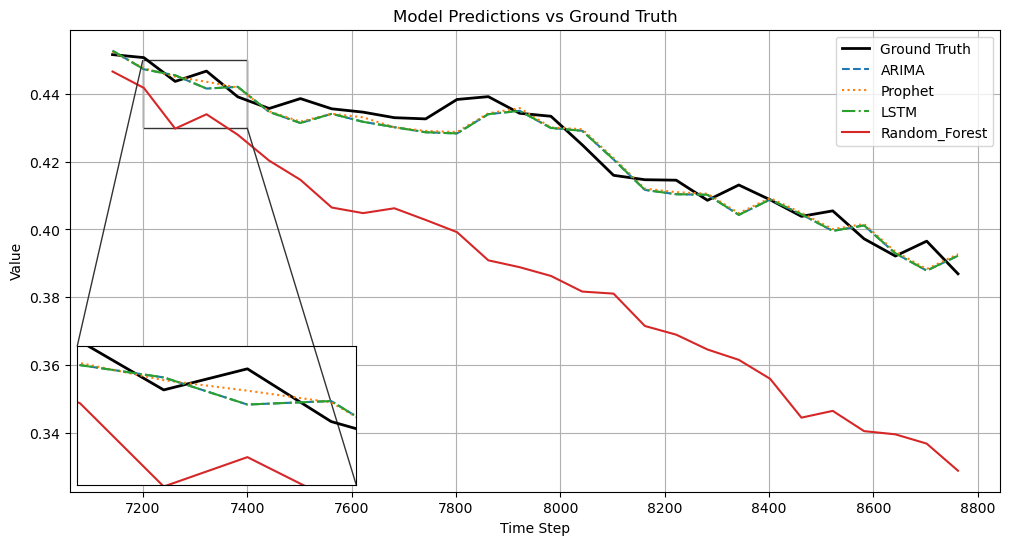

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(12, 6))

# --- main plot ---
ax.plot(test_3.index, y_true, label="Ground Truth", color="black", linewidth=2)
ax.plot(test_3.index, y_pred_arima, label="ARIMA", linestyle="--")
ax.plot(test_3.index, y_pred_prophet, label="Prophet", linestyle=":")
ax.plot(test_3.index, y_pred_lstm, label="LSTM", linestyle="-.")
ax.plot(test_3.index, y_pred_rf, label="Random_Forest", linestyle="-")

ax.legend()
plt.title("Model Predictions vs Ground Truth")
plt.xlabel("Time Step")
plt.ylabel("Value")

ax.grid(True)

axins = inset_axes(ax, width="30%", height="30%", loc="lower left")


axins.plot(test_3.index, y_true, color="black", linewidth=2)
axins.plot(test_3.index, y_pred_arima, linestyle="--")
axins.plot(test_3.index, y_pred_prophet, linestyle=":")
axins.plot(test_3.index, y_pred_lstm, linestyle="-.")
axins.plot(test_3.index, y_pred_rf, label="Random_Forest", linestyle="-")

x1, x2 = 7200, 7400 
axins.set_xlim(x1, x2)

# y zoom
# axins.set_ylim(
#     min(0.4),
#     max(0.46)
# )
axins.set_ylim(0.43, 0.45)

axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel("")
axins.set_ylabel("")

axins.grid(True)

# connect zoom box to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.2")

plt.show()

### 2- training time and forecasting time 

In [29]:
simulation = pd.read_csv("../../noise/macro_noisy.csv")

In [31]:
simulation.head()

,t[s],x_t,y_t,A_sample,A_mean,A_var,A_max,A_min,macro_step_time[s],A_sample_noisy,A_mean_noisy,A_max_noisy,A_min_noisy
0,2.0,20000.0,20000.0,0.999768,0.013218,0.006433,0.999768,-2.829959e-46,0.142123,0.989995,0.008331,0.991949,-0.007819
1,62.0,21000.0,21000.0,0.987603,0.013139,0.006353,0.987603,-2.093811e-45,0.066945,0.976038,0.007356,0.978351,-0.009252
2,122.0,21000.0,21000.0,0.985019,0.013060,0.006274,0.985019,-2.183982e-05,0.124839,0.976572,0.008837,0.978261,-0.006779
3,182.0,22000.0,22000.0,0.979262,0.012982,0.006196,0.979262,-1.562805e-04,0.077798,0.968470,0.007586,0.970628,-0.008790
4,242.0,22000.0,22000.0,0.967426,0.012904,0.006120,0.967426,-3.043655e-04,0.059410,0.954645,0.006513,0.957201,-0.010530


In [32]:
len(test_3)

28

In [63]:
test_3

,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
t,,,,,
7142.0,0.451596,0.457939,-0.006342,-0.004449,-0.008937
7202.0,0.450712,0.451596,-0.000884,-0.006342,-0.005108
7262.0,0.443687,0.450712,-0.007025,-0.000884,-0.008999
7322.0,0.446733,0.443687,0.003046,-0.007025,0.006458
7382.0,0.439125,0.446733,-0.007608,0.003046,-0.004449
7442.0,0.435690,0.439125,-0.003435,-0.007608,-0.006342
7502.0,0.438615,0.435690,0.002925,-0.003435,-0.000884
7562.0,0.435599,0.438615,-0.003016,0.002925,-0.007025
7622.0,0.434615,0.435599,-0.000984,-0.003016,0.003046


In [61]:
len(simulation["macro_step_time[s]"].iloc[-28:])

28

In [64]:
simulation.iloc[-28:]

,t[s],x_t,y_t,A_sample,A_mean,A_var,A_max,A_min,macro_step_time[s],A_sample_noisy,A_mean_noisy,A_max_noisy,A_min_noisy
119,7142.0,91000.0,91000.0,0.461349,0.005809,0.001468,0.461349,-0.001578,0.087882,0.451596,0.000933,0.453547,-0.009381
120,7202.0,92000.0,92000.0,0.460868,0.005761,0.001450,0.460868,-0.001569,0.070069,0.450712,0.000682,0.452743,-0.009694
121,7262.0,93000.0,93000.0,0.455119,0.005711,0.001433,0.455119,-0.001559,0.087710,0.443687,-0.000005,0.445973,-0.010704
122,7322.0,93000.0,93000.0,0.454406,0.005660,0.001415,0.454406,-0.001550,0.130597,0.446733,0.001824,0.448268,-0.007688
123,7382.0,94000.0,94000.0,0.451343,0.005607,0.001398,0.451343,-0.001541,0.059598,0.439125,-0.000502,0.441569,-0.011314
124,7442.0,94000.0,94000.0,0.446807,0.005550,0.001381,0.446807,-0.001531,0.060779,0.435690,-0.000008,0.437913,-0.010425
125,7502.0,95000.0,95000.0,0.446240,0.005490,0.001364,0.446240,-0.001522,0.157728,0.438615,0.001677,0.440140,-0.007622
126,7562.0,96000.0,96000.0,0.440802,0.005425,0.001347,0.440802,-0.001513,0.148168,0.435599,0.002823,0.436640,-0.005676
127,7622.0,96000.0,96000.0,0.440172,0.005353,0.001331,0.440172,-0.001504,0.065913,0.434615,0.002574,0.435726,-0.005950
128,7682.0,97000.0,97000.0,0.436853,0.005272,0.001314,0.436853,-0.001495,0.139902,0.432978,0.003334,0.433753,-0.004595


In [66]:
simulation_test_time=np.sum(simulation["macro_step_time[s]"].iloc[-28:])

In [67]:
simulation_test_time

2.6301066875457755

In [40]:
df = pd.read_csv("../results.csv")
df.head(20)

,part,model,method,mae,nrmse,rmse,smape,r2,train_time,pred_time
0,macro,auto_regression,predict_value,0.021806,0.321958,0.024308,5.390487,-0.489816,0.007739,0.004099
1,macro,auto_regression,predict_delta_y,0.003610,0.068169,0.004411,0.860606,0.942265,0.008247,0.005358
2,macro,arima,predict_value,0.021311,0.315960,0.023855,5.267054,-0.434825,0.279347,0.014534
3,macro,arima,predict_delta_y,0.003631,0.068105,0.004407,0.862916,0.942374,1.788533,0.023556
4,macro,prophet,predict_value,0.041061,0.610302,0.046078,10.531277,-4.353332,1.607518,1.782403
5,macro,prophet,predict_value,0.041061,0.610302,0.046078,10.531277,-4.353332,0.905304,1.499184
6,macro,prophet,predict_delta_y,0.003589,0.066892,0.004329,0.855731,0.944408,0.660599,1.777499
7,macro,random_forest,predict_delta_y,0.037432,0.635160,0.041101,9.524147,-4.012205,0.575643,1.528331
8,macro,lstm,predict_delta_y,0.003747,0.070318,0.004550,0.891366,0.938567,13.074292,2.916768


In [48]:
df_filtered = df[(df["method"] == "predict_delta_y") & (df["model"] != "auto_regression")]
df_filtered.head()

,part,model,method,mae,nrmse,rmse,smape,r2,train_time,pred_time
3,macro,arima,predict_delta_y,0.003631,0.068105,0.004407,0.862916,0.942374,1.788533,0.023556
6,macro,prophet,predict_delta_y,0.003589,0.066892,0.004329,0.855731,0.944408,0.660599,1.777499
7,macro,random_forest,predict_delta_y,0.037432,0.635160,0.041101,9.524147,-4.012205,0.575643,1.528331
8,macro,lstm,predict_delta_y,0.003747,0.070318,0.004550,0.891366,0.938567,13.074292,2.916768


In [131]:
models = df_filtered["model"]

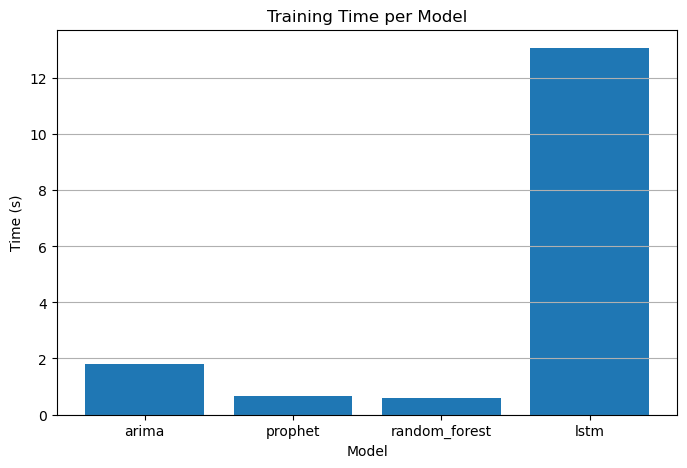

In [51]:
# =========================
# 1. TRAINING TIME
# =========================
plt.figure(figsize=(8,5))
plt.bar(models, df_filtered["train_time"])
plt.title("Training Time per Model")
plt.ylabel("Time (s)")
plt.xlabel("Model")
plt.grid(axis="y")
plt.show()

['arima' 'prophet' 'random_forest' 'lstm' 'simulation']
[0.0235557  1.7774989  1.5283307  2.9167678  2.63010669]


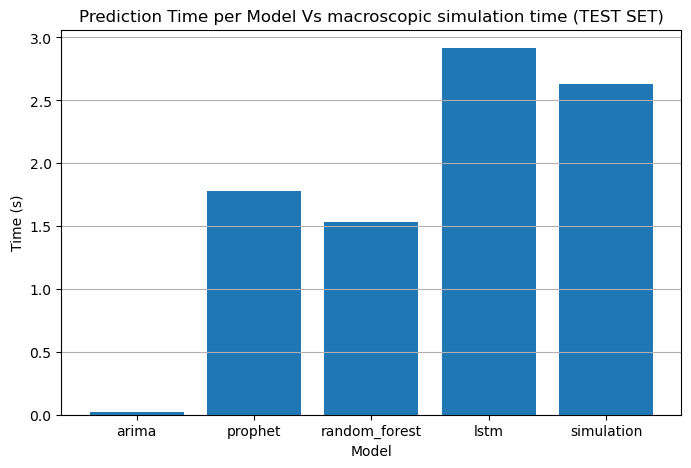

In [75]:
# =========================
# 2. PREDICTION TIME
# =========================
models_simulations = np.append(models,"simulation")
print(models_simulations)
values =  df_filtered["pred_time"].copy()
values = np.append(values,simulation_test_time)
print(values)
plt.figure(figsize=(8,5))
plt.bar(models_simulations,values )
plt.title("Prediction Time per Model Vs macroscopic simulation time (TEST SET)")
plt.ylabel("Time (s)")
plt.xlabel("Model")
plt.grid(axis="y")
plt.show()

C:\Users\jm_kh\AppData\Local\Temp\ipykernel_30756\3808981981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["total_time"] = df_filtered["train_time"] + df_filtered["pred_time"]


['arima' 'prophet' 'random_forest' 'lstm' 'simulation']
[ 1.8120883   2.4380983   2.1039737  15.9910593   2.63010669]


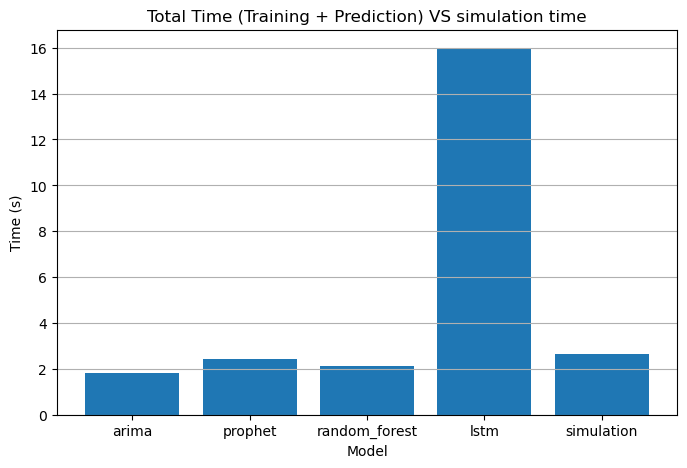

In [116]:
# =========================
# 3. TOTAL TIME
# =========================
df_filtered["total_time"] = df_filtered["train_time"] + df_filtered["pred_time"]
models_simulations = np.append(models,"simulation")
print(models_simulations)
values =  df_filtered["total_time"].copy()
values = np.append(values,simulation_test_time)
print(values)
plt.figure(figsize=(8,5))
plt.bar(models_simulations, values)
plt.title("Total Time (Training + Prediction) VS simulation time")
plt.ylabel("Time (s)")
plt.xlabel("Model")
plt.grid(axis="y")
plt.show()


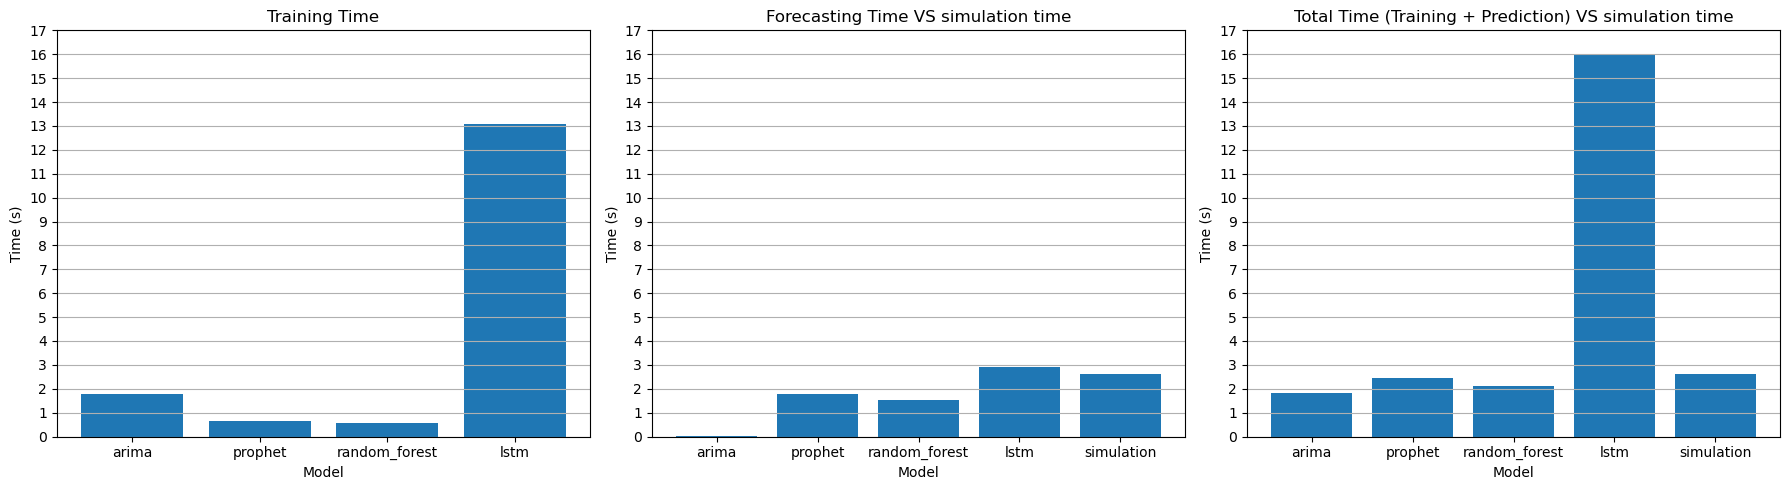

In [133]:
y_max = np.ceil(16.5 / 1) * 1
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# training
axs[0].bar(models, df_filtered["train_time"])
axs[0].set_title("Training Time")

# prediction
axs[1].bar(models_simulations, np.append(df_filtered["pred_time"],simulation_test_time))
axs[1].set_title("Forecasting Time VS simulation time")

# total
axs[2].bar(models_simulations, values)
axs[2].set_title("Total Time (Training + Prediction) VS simulation time")

for ax in axs:
    ax.set_xlabel("Model")
    ax.set_ylabel("Time (s)")
    ax.set_ylim(0, y_max)
    ax.set_yticks(np.arange(0, y_max + 1, 1))
    ax.grid(axis="y")

plt.tight_layout()
plt.show()

3    0.023556
6    1.777499
7    1.528331
8    2.916768
Name: pred_time, dtype: float64


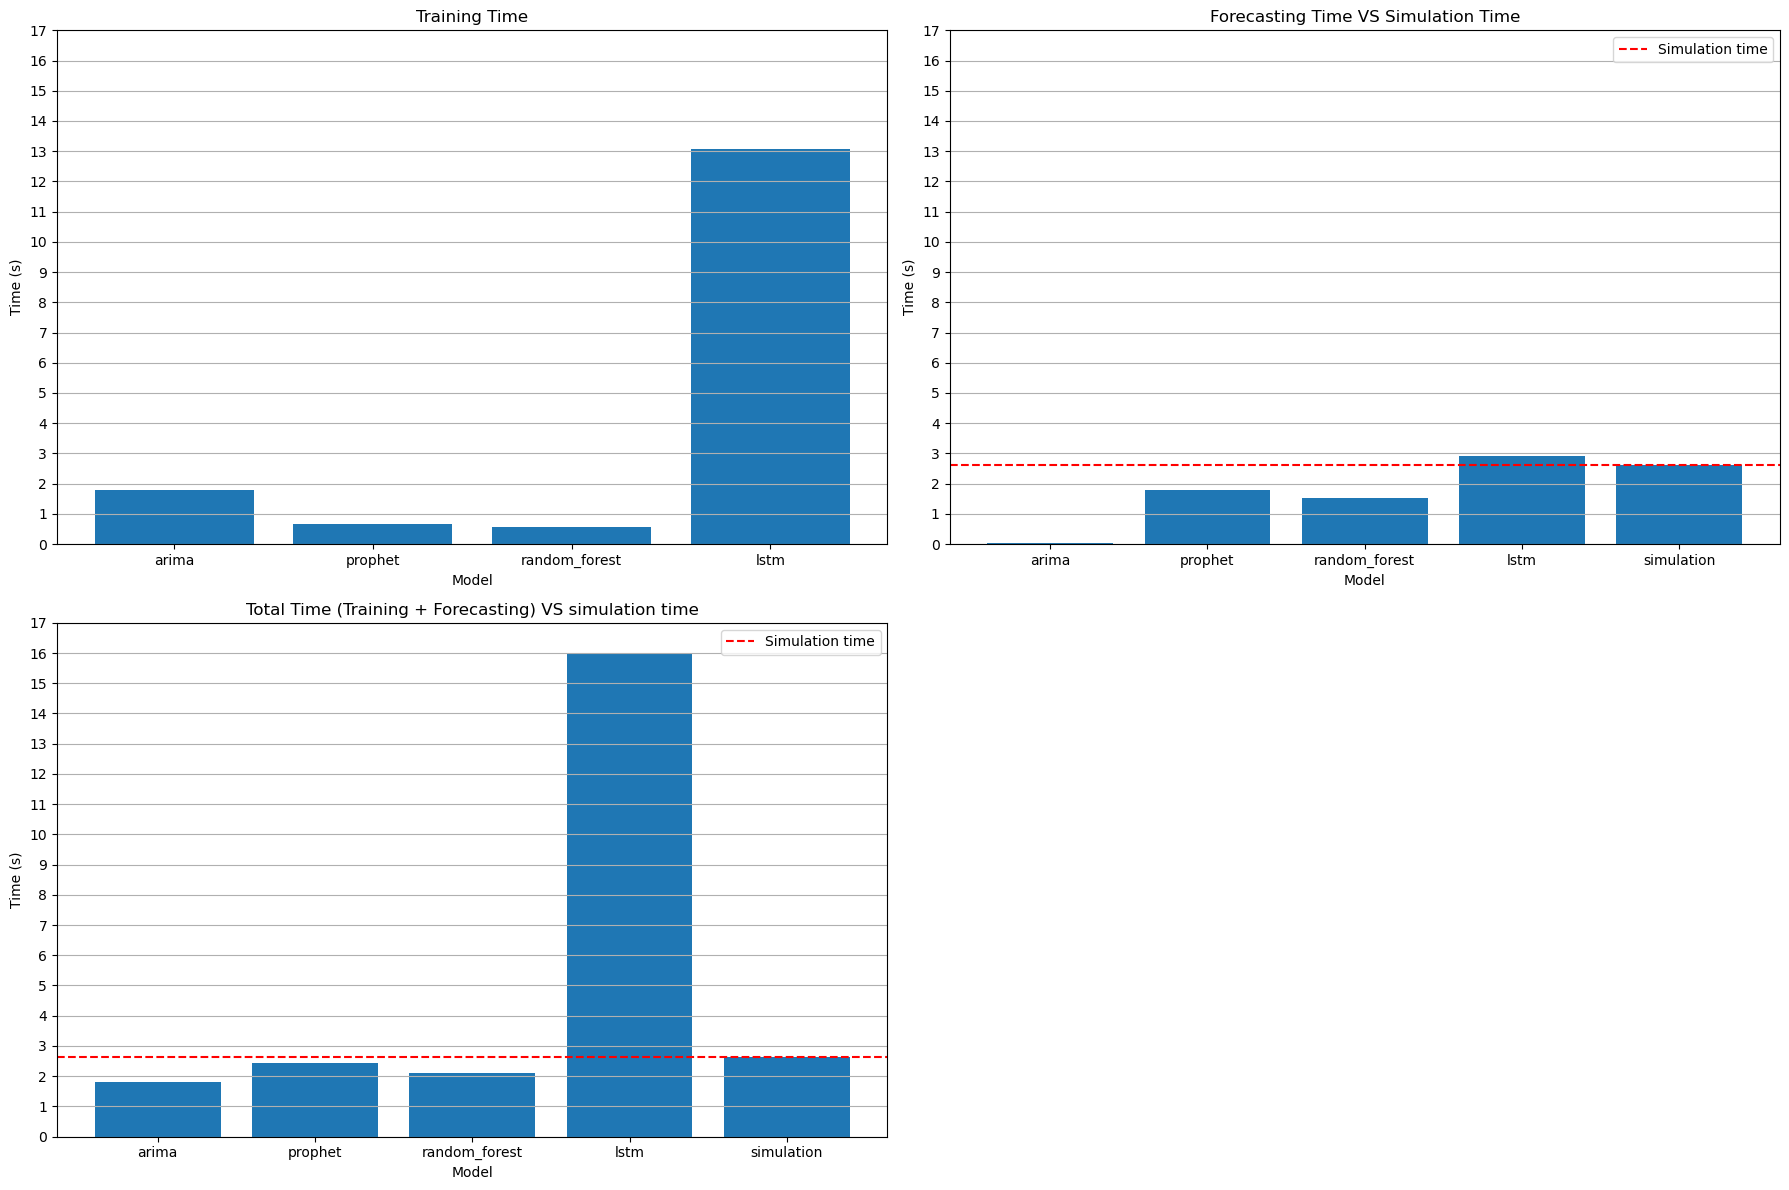

In [139]:
y_max = np.ceil(16.5 / 1) * 1

# =========================================================
# Figure
# =========================================================
print(df_filtered["pred_time"])
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.flatten()

# =========================================================
# Training time
# =========================================================

axs[0].bar(models, df_filtered["train_time"])
axs[0].set_title("Training Time")

# =========================================================
# Prediction time vs simulation
# =========================================================

axs[1].bar(models_simulations, np.append(df_filtered["pred_time"],simulation_test_time))
axs[1].axhline(simulation_test_time, linestyle="--", color="red", label="Simulation time")
axs[1].set_title("Forecasting Time VS Simulation Time")
axs[1].legend()
# =========================================================
# Total time
# =========================================================

axs[2].bar(models_simulations, values)
axs[2].axhline(simulation_test_time, linestyle="--", color="red", label="Simulation time")
axs[2].set_title("Total Time (Training + Forecasting) VS simulation time")
axs[2].legend()

# =========================================================
# Remove empty subplot
# =========================================================

fig.delaxes(axs[3])

# =========================================================
# Formatting
# =========================================================

for ax in axs[:3]:
    ax.set_xlabel("Model")
    ax.set_ylabel("Time (s)")
    ax.set_ylim(0, y_max)
    ax.set_yticks(np.arange(0, y_max + 1,1))
    ax.grid(axis="y")

plt.tight_layout()
plt.show()

### 3- Metrics

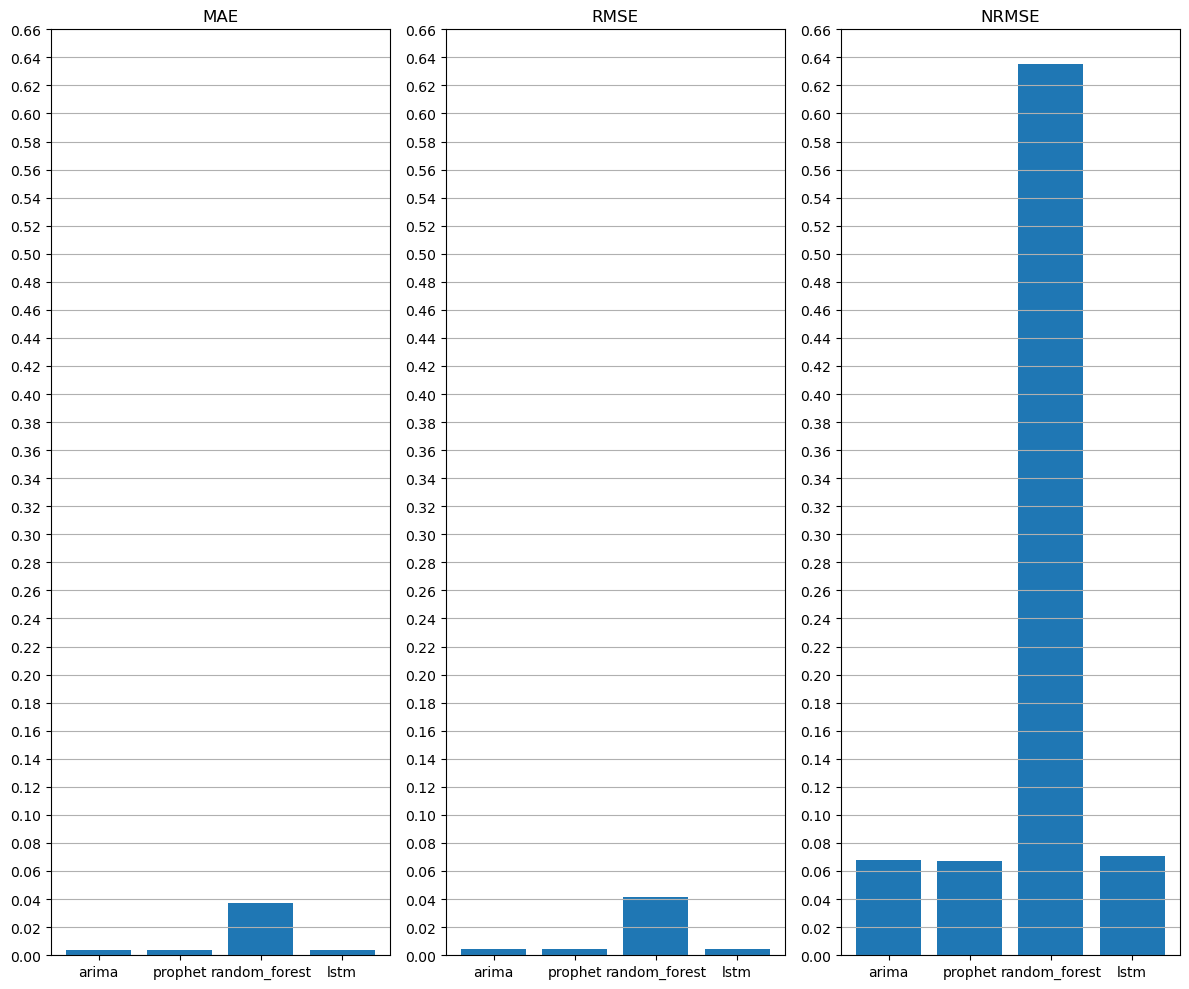

In [94]:
y_max = np.ceil(0.66/ 0.02) * 0.02
metrics = ["mae", "rmse", "nrmse"]

fig, axs = plt.subplots(1, 3, figsize=(12,10))

for i, metric in enumerate(metrics):
    axs[i].bar(models, df_filtered[metric])
    axs[i].set_title(metric.upper())
    axs[i].set_ylim(0, y_max)
    axs[i].set_yticks(np.arange(0, y_max + 0.02, 0.02))
    axs[i].grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\jm_kh\AppData\Local\Temp\ipykernel_30756\437885175.py:9: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axs[i].set_ylim(-4,0, y_max)


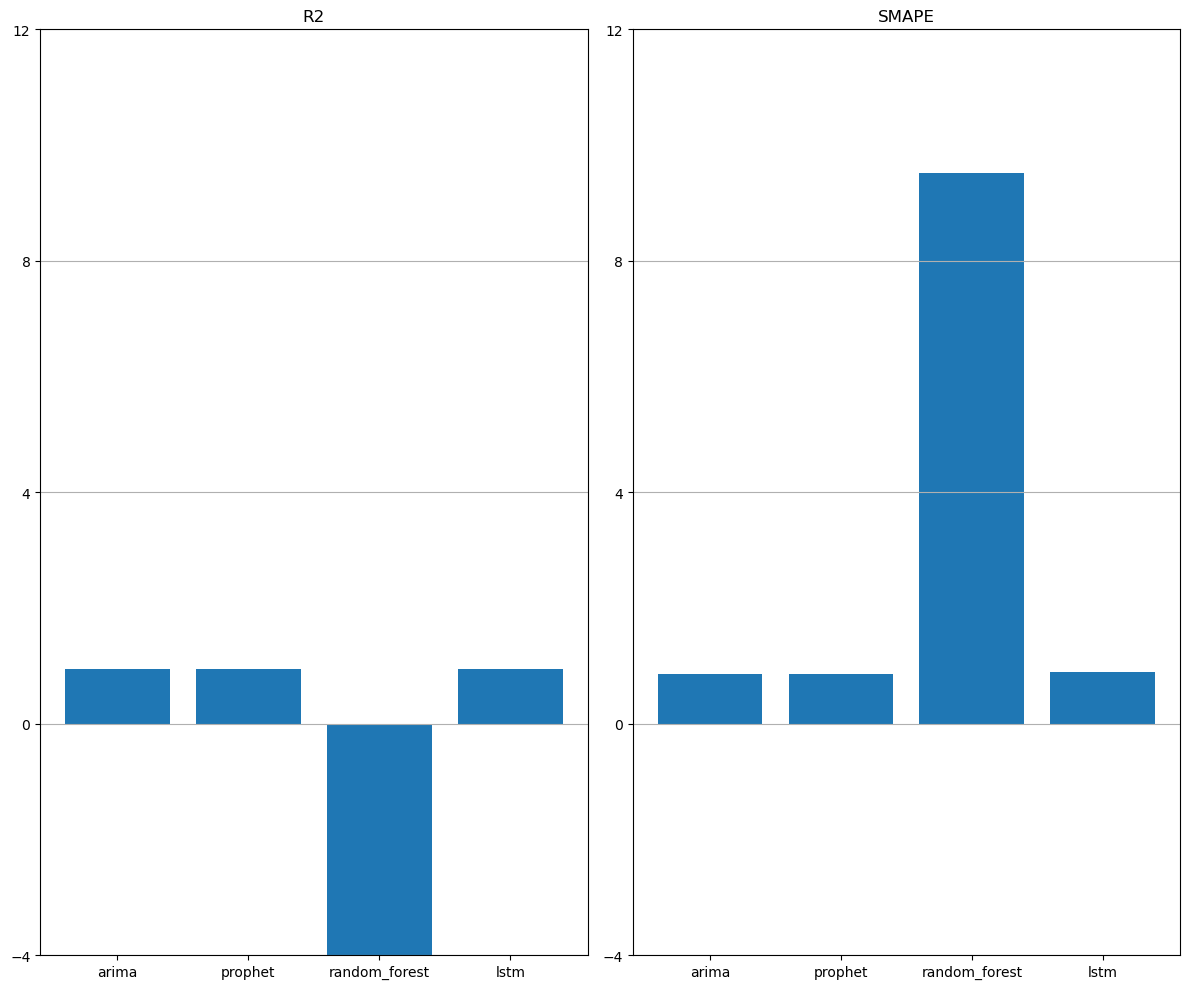

In [102]:
y_max = np.ceil(10/ 4) * 4
metrics = ["r2", "smape"]  

fig, axs = plt.subplots(1, 2, figsize=(12,10))

for i, metric in enumerate(metrics):
    axs[i].bar(models, df_filtered[metric])
    axs[i].set_title(metric.upper())
    axs[i].set_ylim(-4,0, y_max)
    axs[i].set_yticks(np.arange(-4, y_max + 4, 4))
    axs[i].grid(axis="y")

plt.tight_layout()
plt.show()

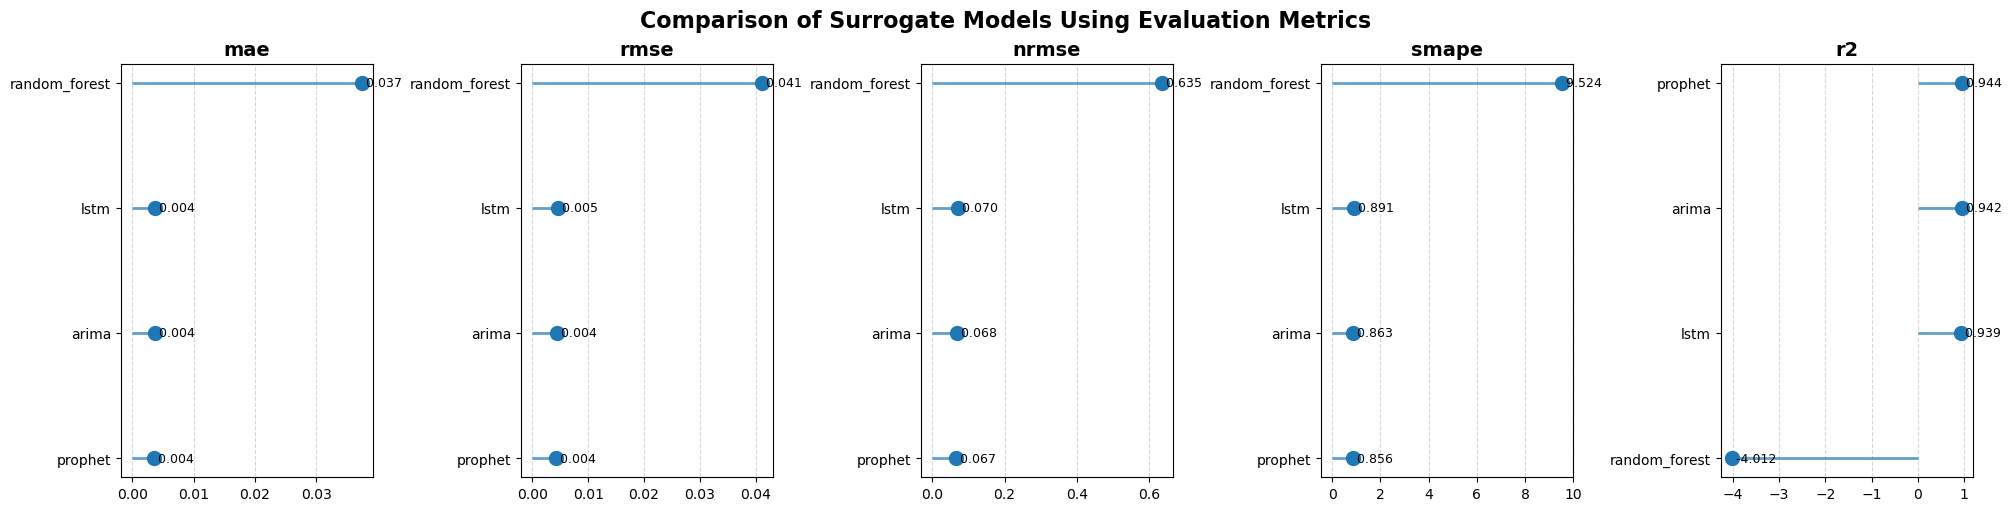

In [106]:
metrics = ["mae", "rmse", "nrmse", "smape", "r2"]
fig, axes = plt.subplots(
    1,
    len(metrics),
    figsize=(20, 5),
    constrained_layout=True
)

# =========================================================
# Cleveland Dot Plot
# =========================================================

for ax, metric in zip(axes, metrics):

    # Lower is better except for R²
    ascending = metric != "R2"

    # Sort dataframe according to current metric
    df_sorted = df_filtered.sort_values(
        by=metric,
        ascending=ascending
    )

    # Y positions
    y = np.arange(len(df_sorted))

    # Horizontal guide lines
    ax.hlines(
        y=y,
        xmin=0,
        xmax=df_sorted[metric],
        linewidth=2,
        alpha=0.7
    )

    # Dots
    ax.plot(
        df_sorted[metric],
        y,
        "o",
        markersize=10
    )

    # Model labels
    ax.set_yticks(y)
    ax.set_yticklabels(df_sorted["model"])

    # Metric title
    ax.set_title(metric, fontsize=14, fontweight="bold")

    # Grid
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    # Better readability
    ax.tick_params(axis='both', labelsize=10)

    # Optional: display values near dots
    for i, value in enumerate(df_sorted[metric]):
        ax.text(
            value,
            i,
            f" {value:.3f}",
            va="center",
            fontsize=9
        )

# =========================================================
# Global title
# =========================================================

fig.suptitle(
    "Comparison of Surrogate Models Using Evaluation Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.show()

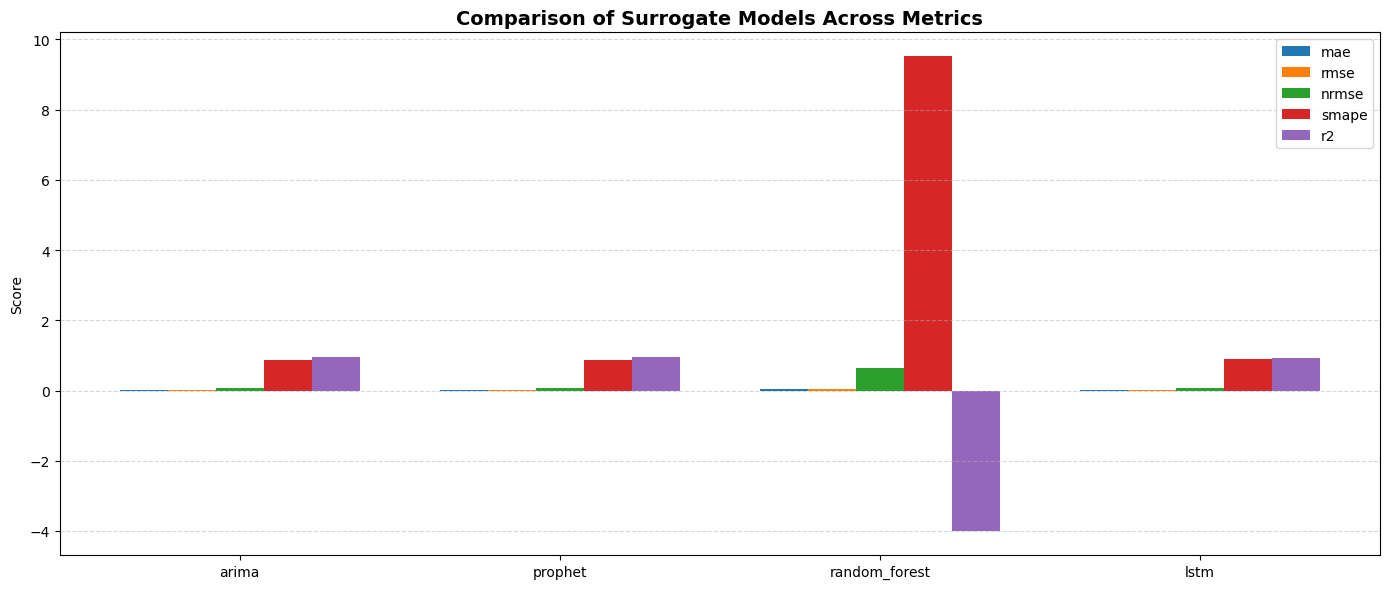

In [107]:
models = df_filtered["model"].values
# =========================================================
# Bar positions
# =========================================================

x = np.arange(len(models))
width = 0.15  # width of each bar

# =========================================================
# Figure
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

# =========================================================
# Plot each metric as a group of bars
# =========================================================

for i, metric in enumerate(metrics):
    ax.bar(
        x + i * width,
        df_filtered[metric],
        width,
        label=metric
    )

# =========================================================
# Formatting
# =========================================================

ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(models)

ax.set_title("Comparison of Surrogate Models Across Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

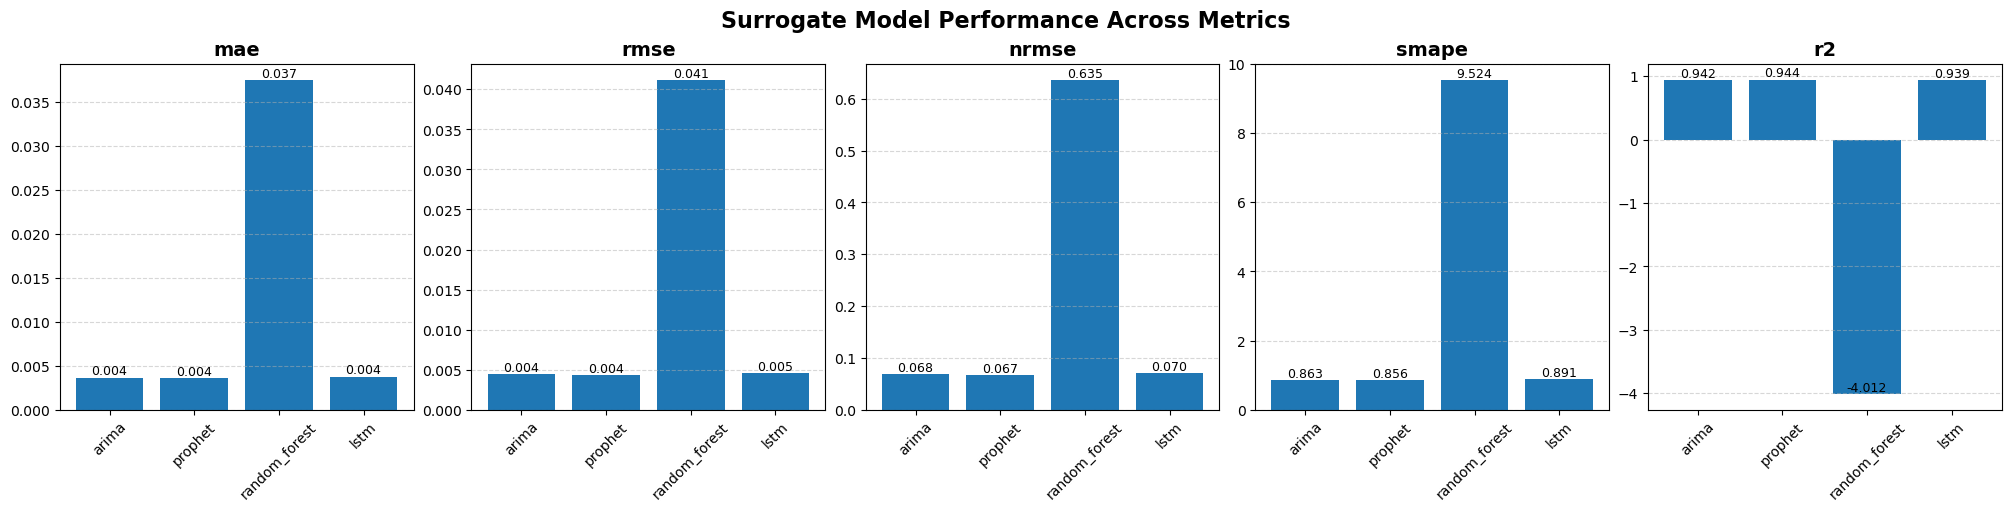

In [108]:
x = np.arange(len(models))

# =========================================================
# Figure with subplots
# =========================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics),
    figsize=(20, 5),
    constrained_layout=True
)

# =========================================================
# Plot each metric separately
# =========================================================

for ax, metric in zip(axes, metrics):

    values = df_filtered[metric].values

    # Bar plot
    ax.bar(models, values)

    # Title
    ax.set_title(metric, fontsize=14, fontweight="bold")

    # Grid
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Improve readability
    ax.tick_params(axis='x', rotation=45)

    # Optional: annotate values on top of bars
    for i, v in enumerate(values):
        ax.text(
            i,
            v,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# =========================================================
# Global title
# =========================================================

fig.suptitle(
    "Surrogate Model Performance Across Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.show()

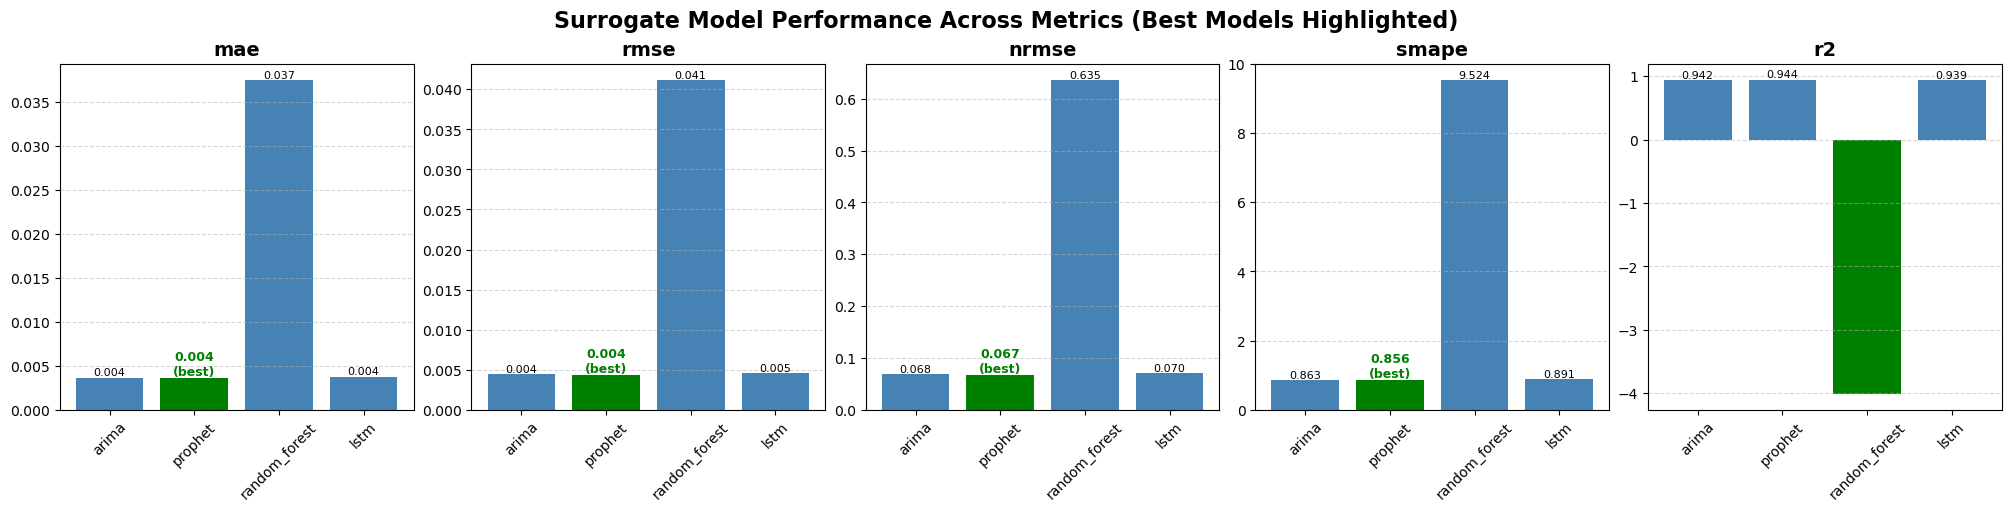

In [109]:
# =========================================================
# Figure setup
# =========================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics),
    figsize=(20, 5),
    constrained_layout=True
)

# =========================================================
# Plot each metric
# =========================================================

for ax, metric in zip(axes, metrics):

    values = df_filtered[metric].values

    # Determine best model index
    if metric == "R2":
        best_idx = np.argmax(values)  # higher is better
    else:
        best_idx = np.argmin(values)  # lower is better

    # Colors: highlight best model
    colors = ["steelblue"] * len(values)
    colors[best_idx] = "green"

    # Bar plot
    bars = ax.bar(models, values, color=colors)

    # Title
    ax.set_title(metric, fontsize=14, fontweight="bold")

    # Grid
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Rotate labels for readability
    ax.tick_params(axis='x', rotation=45)

    # Annotate values + mark best
    for i, v in enumerate(values):
        if i == best_idx:
            ax.text(
                i,
                v,
                f"{v:.3f}\n(best)",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="green"
            )
        else:
            ax.text(
                i,
                v,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

# =========================================================
# Global title
# =========================================================

fig.suptitle(
    "Surrogate Model Performance Across Metrics (Best Models Highlighted)",
    fontsize=16,
    fontweight="bold"
)

plt.show()

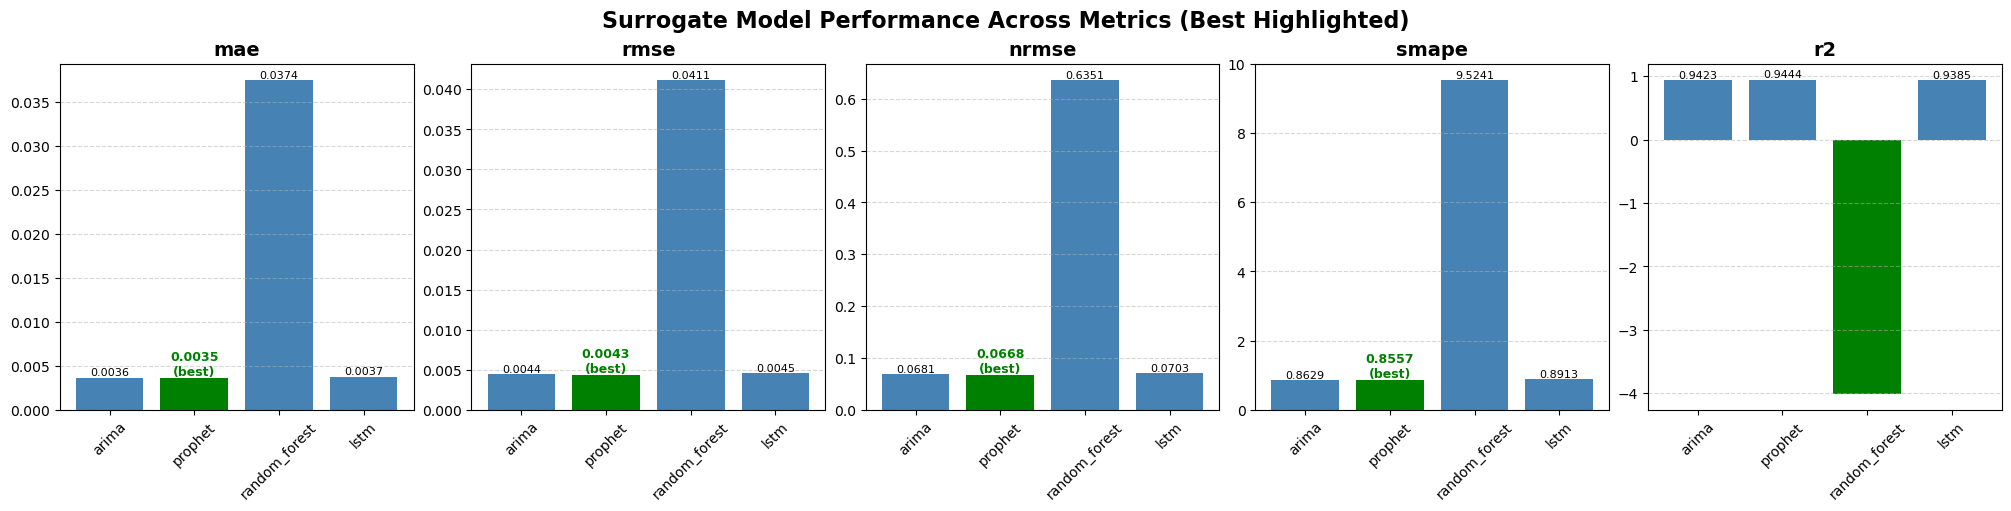

In [110]:
def truncate_4(x):
    return np.trunc(x * 10000) / 10000

fig, axes = plt.subplots(
    1,
    len(metrics),
    figsize=(20, 5),
    constrained_layout=True
)

for ax, metric in zip(axes, metrics):

    values = df_filtered[metric].values

    # Best model detection
    if metric == "R2":
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)

    colors = ["steelblue"] * len(values)
    colors[best_idx] = "green"

    ax.bar(models, values, color=colors)

    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

    # annotations with truncation (NOT rounding)
    for i, v in enumerate(values):

        v_trunc = truncate_4(v)

        if i == best_idx:
            ax.text(
                i, v,
                f"{v_trunc}\n(best)",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="green"
            )
        else:
            ax.text(
                i, v,
                f"{v_trunc}",
                ha="center",
                va="bottom",
                fontsize=8
            )

fig.suptitle(
    "Surrogate Model Performance Across Metrics (Best Highlighted)",
    fontsize=16,
    fontweight="bold"
)

plt.show()

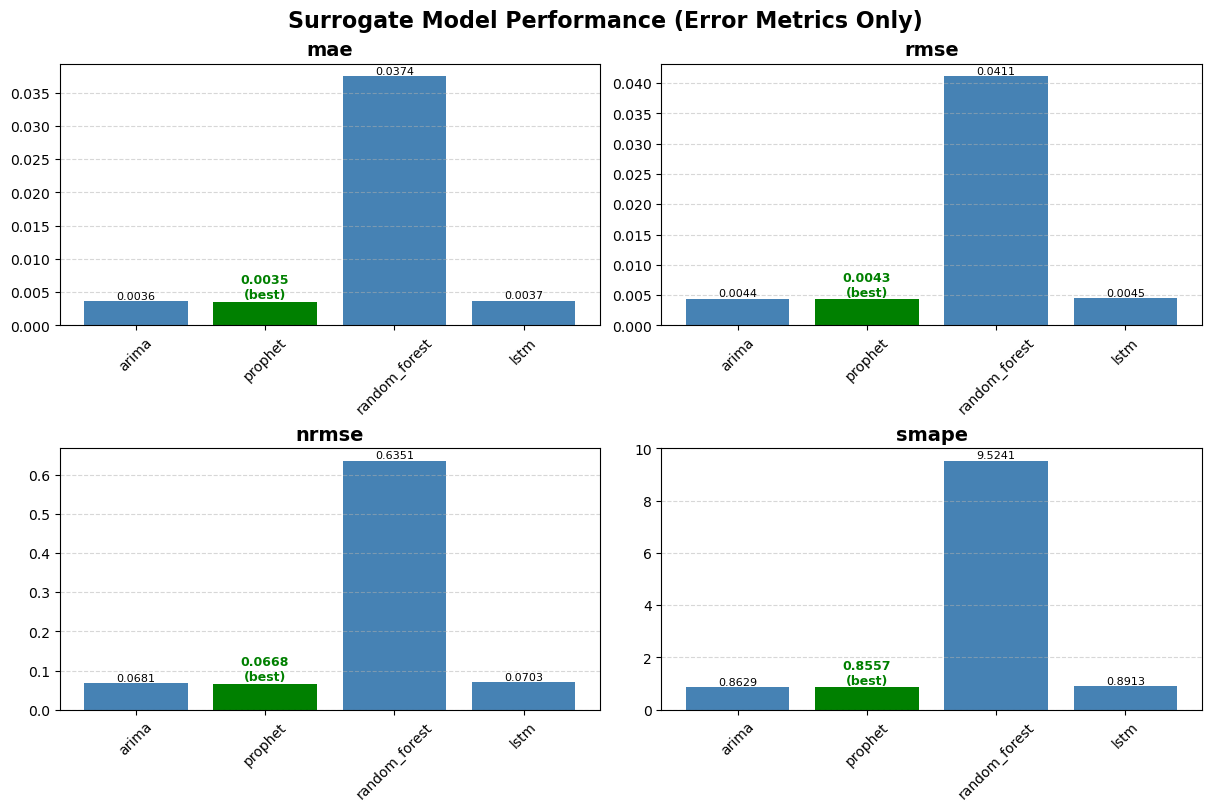

In [111]:
def truncate_4(x):
    return np.trunc(x * 10000) / 10000

# =========================================================
# Figure: 2 rows x 2 columns
# =========================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    constrained_layout=True
)

axes = axes.flatten()

# =========================================================
# Plot each metric
# =========================================================

for ax, metric in zip(axes, metrics):

    values = df_filtered[metric].values

    # Best model (lower is better for all these metrics)
    best_idx = np.argmin(values)

    colors = ["steelblue"] * len(values)
    colors[best_idx] = "green"

    ax.bar(models, values, color=colors)

    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

    # Annotate values (truncated)
    for i, v in enumerate(values):
        v_trunc = truncate_4(v)

        if i == best_idx:
            ax.text(
                i, v,
                f"{v_trunc}\n(best)",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="green"
            )
        else:
            ax.text(
                i, v,
                f"{v_trunc}",
                ha="center",
                va="bottom",
                fontsize=8
            )

# =========================================================
# Global title
# =========================================================

fig.suptitle(
    "Surrogate Model Performance (Error Metrics Only)",
    fontsize=16,
    fontweight="bold"
)

plt.show()